### STEP - 1: Import the libraries

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as py
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier,plot_tree,export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

### STEP - 2: Load the dataset

In [20]:
titanicDF = sns.load_dataset('titanic')
titanicDF.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### STEP - 3: Filter the dataset, with needed features and target variable

In [21]:
features = ['pclass','sex','age','fare','embarked','adult_male','alone']
target = 'survived'

FiltTitanicDf=titanicDF[features+[target]].copy()

### STEP - 4: Fill the missing data in the columns

In [22]:
display(FiltTitanicDf.info())

FiltTitanicDf['age'] = FiltTitanicDf['age'].fillna(FiltTitanicDf['age'].median())
FiltTitanicDf['embarked'] = FiltTitanicDf['embarked'].fillna(FiltTitanicDf['embarked'].mode()[0])

display(FiltTitanicDf.info())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      891 non-null    int64  
 1   sex         891 non-null    str    
 2   age         714 non-null    float64
 3   fare        891 non-null    float64
 4   embarked    889 non-null    str    
 5   adult_male  891 non-null    bool   
 6   alone       891 non-null    bool   
 7   survived    891 non-null    int64  
dtypes: bool(2), float64(2), int64(2), str(2)
memory usage: 43.6 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      891 non-null    int64  
 1   sex         891 non-null    str    
 2   age         891 non-null    float64
 3   fare        891 non-null    float64
 4   embarked    891 non-null    str    
 5   adult_male  891 non-null    bool   
 6   alone       891 non-null    bool   
 7   survived    891 non-null    int64  
dtypes: bool(2), float64(2), int64(2), str(2)
memory usage: 43.6 KB


None

### STEP - 5: Encoding the data(One hot and Label)

In [23]:
#adult_male and alone is already encoded

encodedTitanic = pd.get_dummies(FiltTitanicDf, columns=['embarked','sex'],drop_first=True)

display(encodedTitanic.head())


,pclass,age,fare,adult_male,alone,survived,embarked_Q,embarked_S,sex_male
0,3,22.0,7.2500,True,False,0,False,True,True
1,1,38.0,71.2833,False,False,1,False,False,False
2,3,26.0,7.9250,False,True,1,False,True,False
3,1,35.0,53.1000,False,False,1,False,True,False
4,3,35.0,8.0500,True,True,0,False,True,True


### STEP - 6: Data split

In [26]:
y = encodedTitanic['survived']
x = encodedTitanic.drop(target,axis=1)

xTrain,xTest,yTrain,yTest = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print(f"{xTrain.shape[0]} rows in Training input dataset")
print(f"{yTrain.shape[0]} rows in Training output dataset")
print(f"{xTest.shape[0]} rows in Testing input dataset")
print(f"{yTest.shape[0]} rows in Testing output dataset")

712 rows in Training input dataset
712 rows in Training output dataset
179 rows in Testing input dataset
179 rows in Testing output dataset


## Decision trees do not work on distance measure like in Linear regression, it works like if-else conditions. So, we do not need scaling.

In [27]:
descTree = DecisionTreeClassifier(criterion='gini',
                                  max_depth=4, #Limit depth to prevent overfitting.
                                  min_samples_leaf=10 #Atleast 10 records per leaf/decision node in subsets.
                                  )
descTree.fit(xTrain,yTrain)

print("Deciaion Tree Trained")
print(f"Tree depth: {descTree.get_depth()}")
print(f"No.of leaves: {descTree.get_n_leaves()}")
print(f"No.of features used: {descTree.n_features_in_}")

Deciaion Tree Trained
Tree depth: 4
No.of leaves: 14
No.of features used: 8


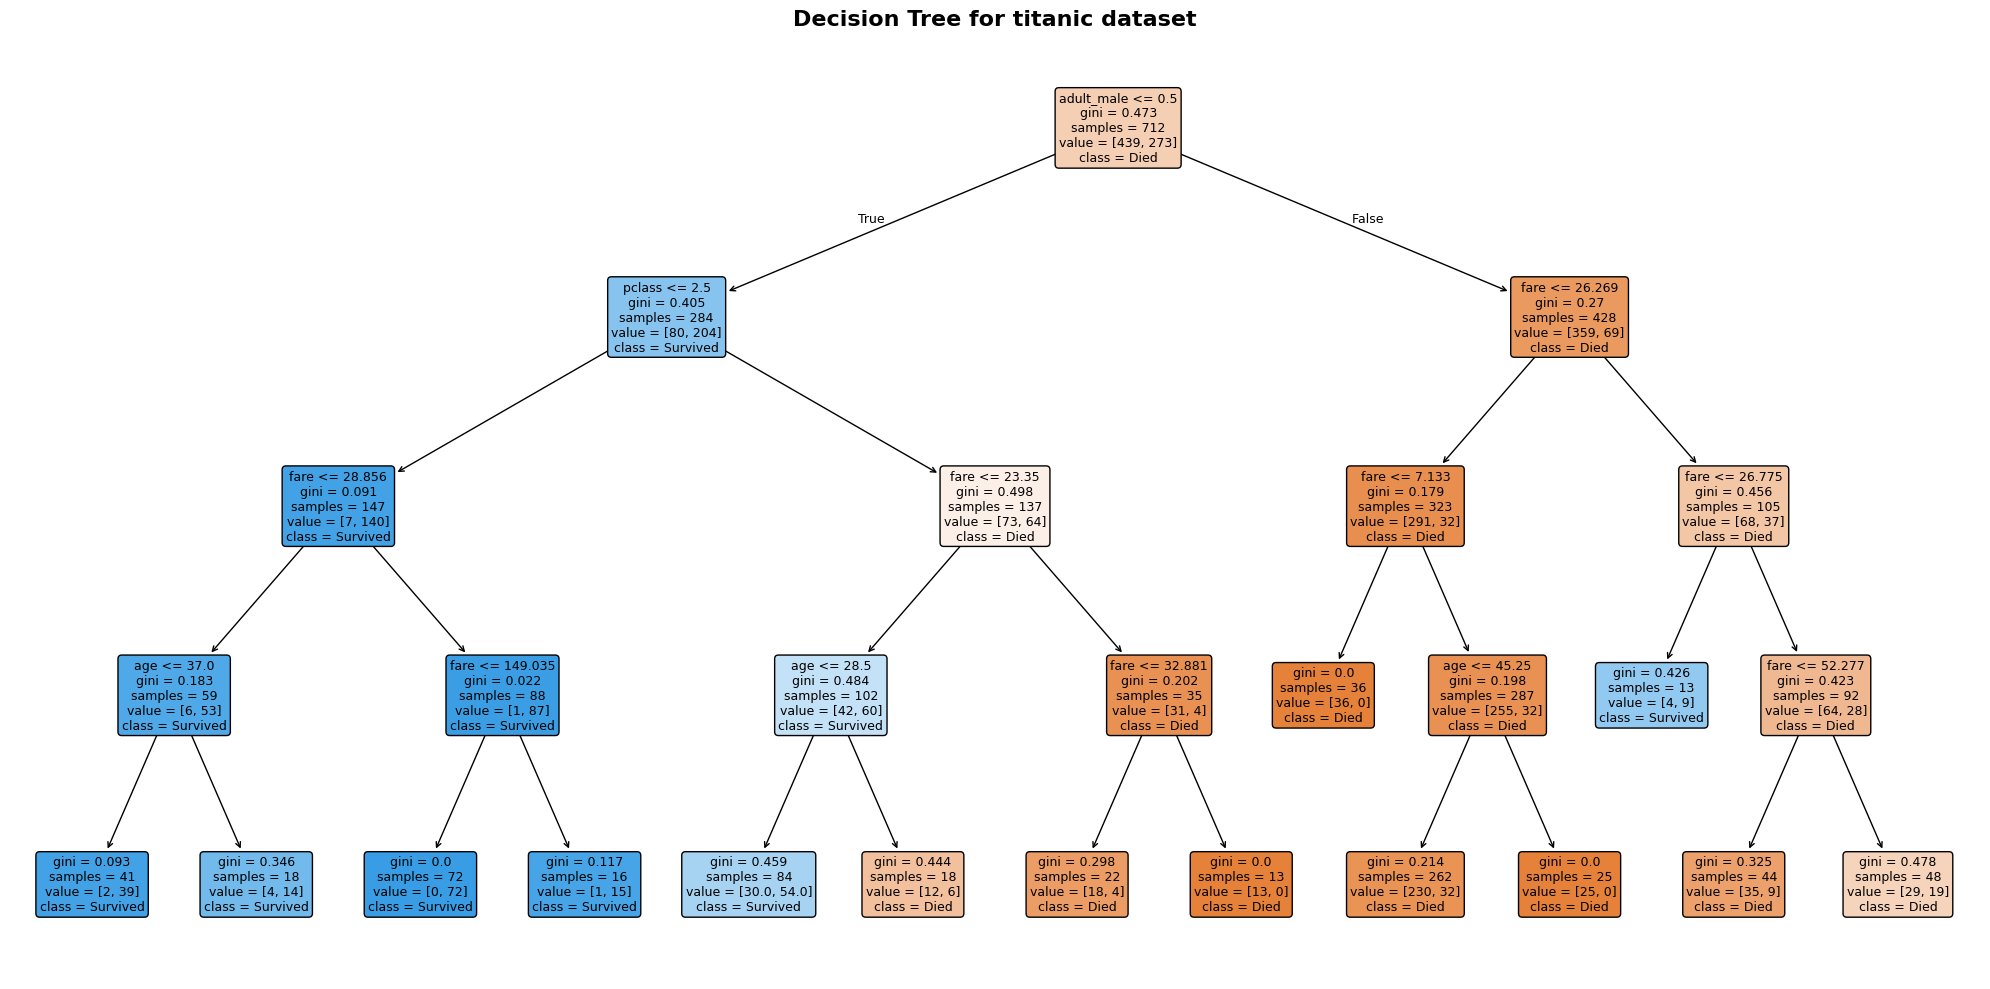

In [31]:
fig,ax = py.subplots(figsize=(20,10))

plot_tree(descTree,
          feature_names=x.columns.to_list(),
          class_names=['Died','Survived'],
          filled=True,rounded=True,fontsize=9,ax=ax
          )
ax.set_title("Decision Tree for titanic dataset",fontsize=16,fontweight='bold')
py.tight_layout()
py.show()


In [32]:
#Print the decision tree as pseudo code:
tree_rules = export_text(descTree,feature_names=x.columns.to_list())
print(f"Decision tree rules:")
print("="*80)
print(tree_rules)

Decision tree rules:
|--- adult_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 28.86
|   |   |   |--- age <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- age >  37.00
|   |   |   |   |--- class: 1
|   |   |--- fare >  28.86
|   |   |   |--- fare <= 149.04
|   |   |   |   |--- class: 1
|   |   |   |--- fare >  149.04
|   |   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 23.35
|   |   |   |--- age <= 28.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  28.50
|   |   |   |   |--- class: 0
|   |   |--- fare >  23.35
|   |   |   |--- fare <= 32.88
|   |   |   |   |--- class: 0
|   |   |   |--- fare >  32.88
|   |   |   |   |--- class: 0
|--- adult_male >  0.50
|   |--- fare <= 26.27
|   |   |--- fare <= 7.13
|   |   |   |--- class: 0
|   |   |--- fare >  7.13
|   |   |   |--- age <= 45.25
|   |   |   |   |--- class: 0
|   |   |   |--- age >  45.25
|   |   |   |   |--- class: 0
|   |--- fare >  26.27
|   |   |--- fare <= 26.77
|   |   |   |--- c

In [ ]:
yTestPred = descTree.predict(xTest)

trainAcc = descTree.score(xTrain,yTrain)
testAcc = descTree.score(xTest,yTest)

print(f"Training accuracy: {trainAcc}")
print(f"Testing accuracy: {testAcc}")
print(f"Checking for overfitting : {trainAcc-testAcc : .4f}")

print("classification Report::: ")
print(classification_report(yTest,yTestPred,target_names=['Survived','Died']))

Training accuracy: 0.8441011235955056
Testing accuracy: 0.8212290502793296
Checking for overfitting :  0.0229
classification Report::: 
              precision    recall  f1-score   support

    Survived       0.84      0.88      0.86       110
        Died       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [36]:
descTree.feature_importances_

array([0.19342834, 0.02475676, 0.16798235, 0.61383255, 0.        ,
       0.        , 0.        , 0.        ])

In [38]:
featureImp = pd.DataFrame({
    'Features':x.columns,
    'Importance':descTree.feature_importances_
}).sort_values('Importance',ascending=False)
print(featureImp)

     Features  Importance
3  adult_male    0.613833
0      pclass    0.193428
2        fare    0.167982
1         age    0.024757
4       alone    0.000000
5  embarked_Q    0.000000
6  embarked_S    0.000000
7    sex_male    0.000000


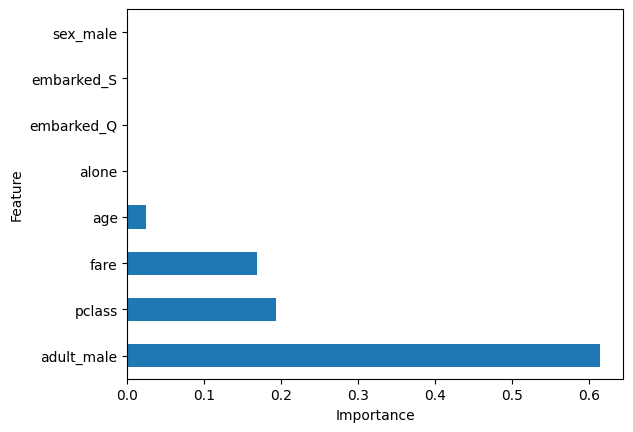

In [40]:
featureImp.plot.barh(x='Features',y='Importance',legend=False)
py.xlabel("Importance")
py.ylabel("Feature")
py.show()

#### Decision Trees are so greedy, they try to pick every best split. Even if two columns have very minor point level difference, the model will pick the less gini impurity, and proceed with split. It only cares about the current step, not the later output. To prevent or overcome this, we have ***RANDOM FOREST***